## Introduction

Financial loan services are leveraged by companies across many industries, from big banks to financial institutions to government loans. One of the primary objectives of companies with financial loan services is to decrease payment defaults and ensure that individuals are paying back their loans as expected. In order to do this efficiently and systematically, many companies employ machine learning to predict which individuals are at the highest risk of defaulting on their loans, so that proper interventions can be effectively deployed to the right audience.

## Objectives

Perform data cleaning and preprocessing on the loan dataset

Discover and interpret key trends and relationships in the data

Build, test, and compare different machine learning models

Identify the most accurate model for predicting loan repayment behavior

## About the Dataset

Rows: 255348

Columns: 18

This dataset contains historical loan application records with information such as:

Loan details: loan amount, term, interest rate

Applicant details: employment length, annual income, home ownership

## importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df=pd.read_csv('Loan_default_new.csv')

In [5]:
df

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


## data exploration

In [6]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [7]:
df.shape

(255347, 18)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [9]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


## Data Cleaning

In [11]:

# 1️ Check for missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# 2️ Check percentage of missing values

missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of Missing Values:")
print(missing_percent.sort_values(ascending=False))

# 3️ Check for duplicate rows
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

# 4️ Check for data types
print("\nData Types:")
print(df.dtypes)

# 5️ Display shape of dataset before cleaning
print("\nShape before cleaning:", df.shape)


Missing Values in Each Column:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Percentage of Missing Values:
LoanID            0.0
Age               0.0
Income            0.0
LoanAmount        0.0
CreditScore       0.0
MonthsEmployed    0.0
NumCreditLines    0.0
InterestRate      0.0
LoanTerm          0.0
DTIRatio          0.0
Education         0.0
EmploymentType    0.0
MaritalStatus     0.0
HasMortgage       0.0
HasDependents     0.0
LoanPurpose       0.0
HasCoSigner       0.0
Default           0.0
dtype: float64

Number of Duplicate Rows: 0

Data Types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditSc

In [12]:
# Convert date columns to datetime (if any)
date_cols = [col for col in df.columns if 'date' in col.lower()]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert data types where needed (object → numeric if possible)
for col in df.select_dtypes(include=['object']).columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# Fix inconsistent categorical data (like YES/Yes/yes)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].replace({
        'Yes': 'yes', 'YES': 'yes', 'Y': 'yes',
        'No': 'no', 'NO': 'no', 'N': 'no'
    })

# Rename columns (clean names)
df = df.rename(columns=lambda x: x.strip().lower().replace(' ', '_'))


C:\Users\shadi\AppData\Local\Temp\ipykernel_31108\3135022730.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [13]:
# Drop rows with too many missing values (more than 50%)
df = df.dropna(thresh=len(df.columns) * 0.5)

# Fill missing numeric values with median
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill missing categorical values with 'Unknown'
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna('Unknown')


In [14]:
# Drop duplicate rows
df = df.drop_duplicates()

# Show how much data changed
print("\nShape after cleaning:", df.shape)



Shape after cleaning: (255347, 18)


In [15]:
print("\nRemaining Missing Values After Cleaning:")
print(df.isnull().sum().sum())

print("\nRemaining Duplicates:", df.duplicated().sum())



Remaining Missing Values After Cleaning:
0

Remaining Duplicates: 0


In [17]:
df.columns

Index(['loanid', 'age', 'income', 'loanamount', 'creditscore',
       'monthsemployed', 'numcreditlines', 'interestrate', 'loanterm',
       'dtiratio', 'education', 'employmenttype', 'maritalstatus',
       'hasmortgage', 'hasdependents', 'loanpurpose', 'hascosigner',
       'default'],
      dtype='object')

## univariate analysis

#### Applicant Income Distribution

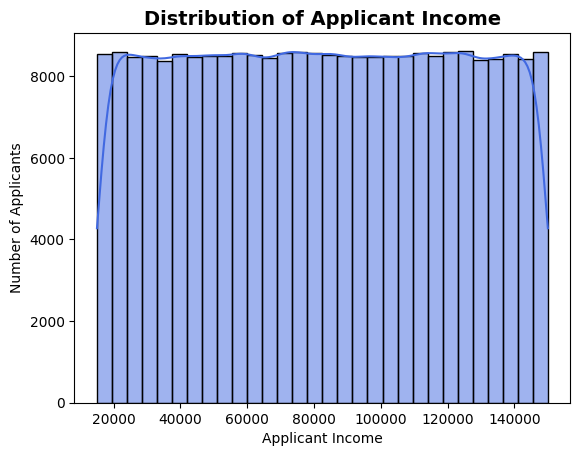

In [18]:
sns.histplot(df['income'], kde=True, bins=30, color='royalblue')
plt.title('Distribution of Applicant Income', fontsize=14, fontweight='bold')
plt.xlabel('Applicant Income')
plt.ylabel('Number of Applicants')
plt.show()


This flat, rectangular shape indicates a uniform distribution. In simple terms, it means there is an almost equal number of applicants in every income bracket shown, from around $20,000 to $150,000.

#### Applicant Age Distribution


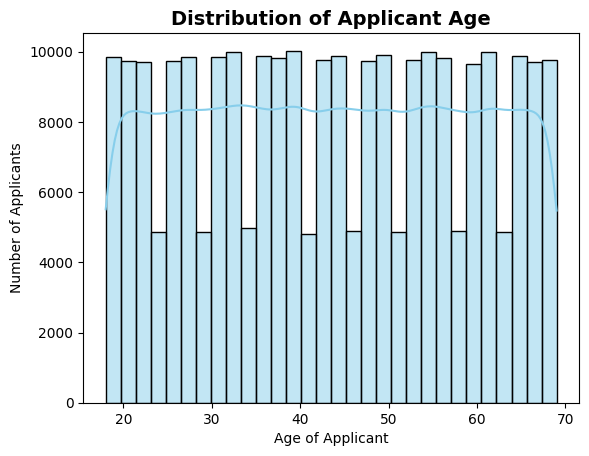

In [19]:
sns.histplot(df['age'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Applicant Age', fontsize=14, fontweight='bold')
plt.xlabel('Age of Applicant')
plt.ylabel('Number of Applicants')
plt.show()



 the overall distribution is fairly uniform. We have a good number of applicants across all age groups, from young adults to those nearing retirement

#### Loan Amount Distribution

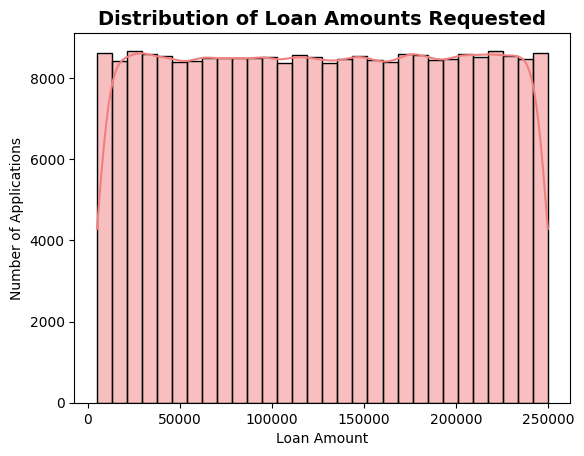

In [20]:
sns.histplot(df['loanamount'], kde=True, bins=30, color='lightcoral')
plt.title('Distribution of Loan Amounts Requested', fontsize=14, fontweight='bold')
plt.xlabel('Loan Amount')
plt.ylabel('Number of Applications')
plt.show()


Just like with the applicant income, we see a distinct uniform distribution. The bars are all roughly the same height, indicating that small, medium, and large loan amounts were all requested with nearly equal frequency

#### Credit Score Distribution

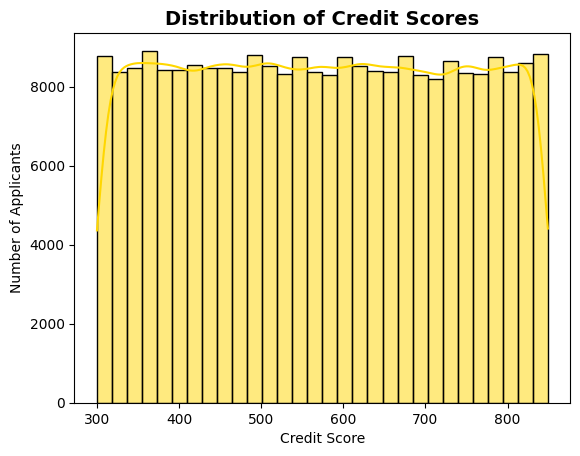

In [21]:
sns.histplot(df['creditscore'], kde=True, bins=30, color='gold')
plt.title('Distribution of Credit Scores', fontsize=14, fontweight='bold')
plt.xlabel('Credit Score')
plt.ylabel('Number of Applicants')
plt.show()


As with the previous features, we see a distinct uniform distribution. There is a nearly equal number of applicants in every credit score bracket. This is highly unusual, as real-world credit score data is typically left-skewed, with more people having good credit scores.

#### Debt-to-Income (DTI) Ratio Distribution

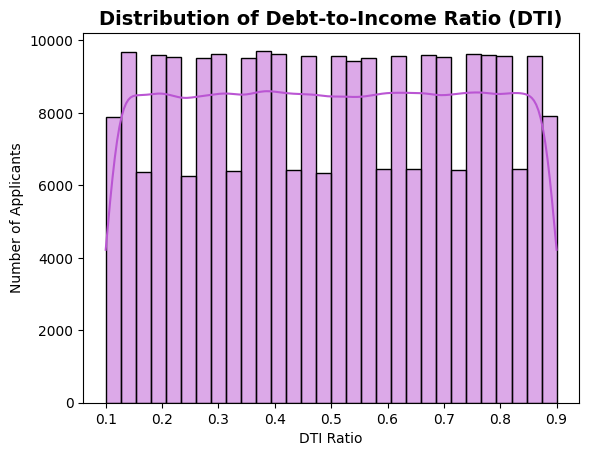

In [22]:
sns.histplot(df['dtiratio'], kde=True, bins=30, color='mediumorchid')
plt.title('Distribution of Debt-to-Income Ratio (DTI)', fontsize=14, fontweight='bold')
plt.xlabel('DTI Ratio')
plt.ylabel('Number of Applicants')
plt.show()


How much of an applicant’s income goes toward debt. Higher DTI ratios may indicate riskier borrowers.

#### Outlier Detection

In [17]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()




In [18]:
num_cols = ['age', 'income', 'loanamount', 'creditscore',
            'monthsemployed', 'numcreditlines', 'interestrate',
            'loanterm', 'dtiratio']


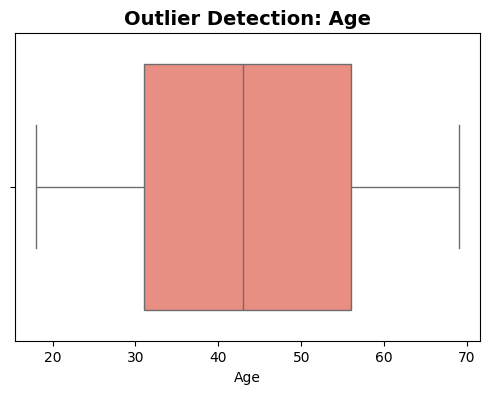

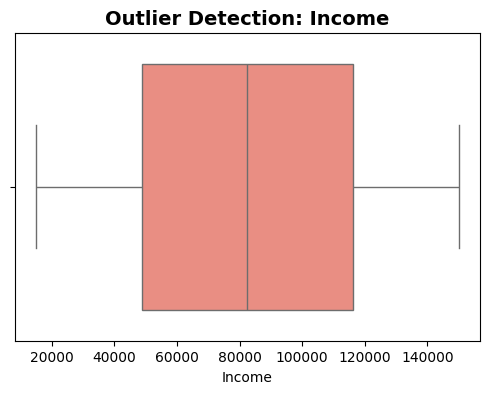

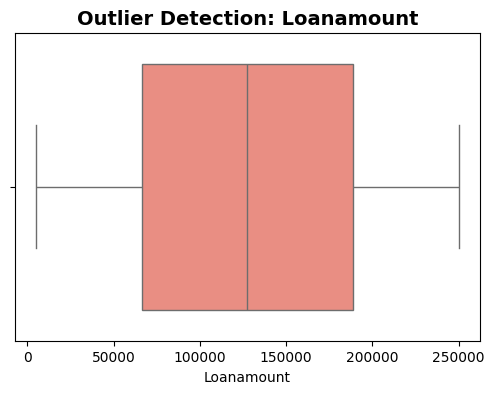

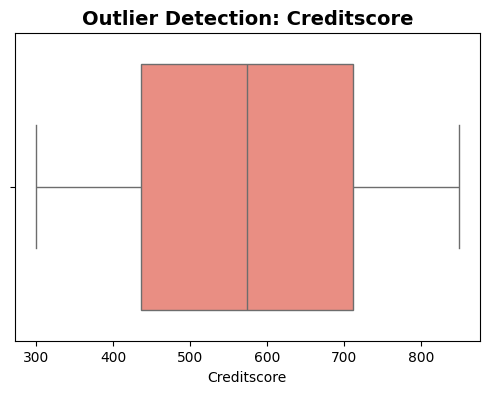

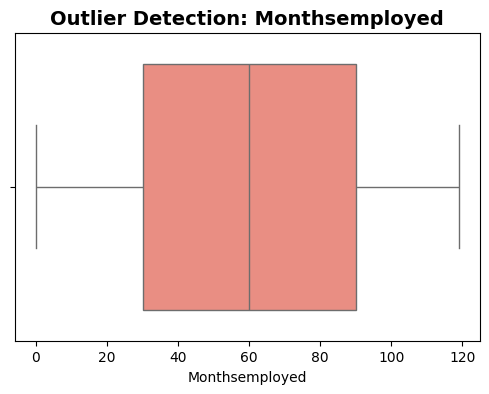

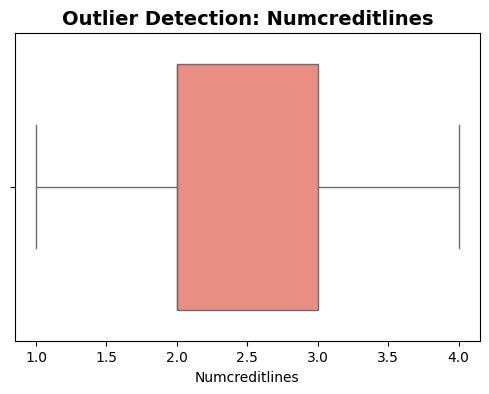

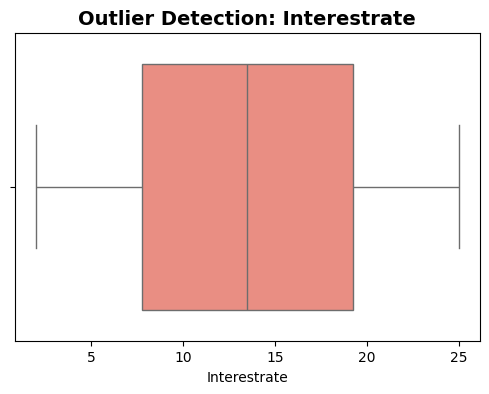

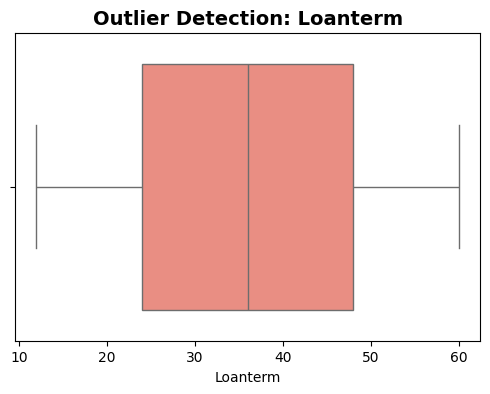

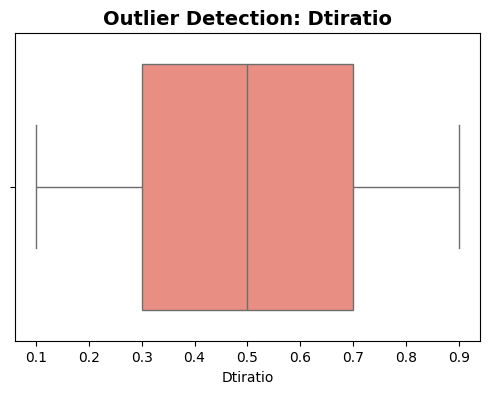

In [19]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color='salmon')
    plt.title(f'Outlier Detection: {col.capitalize()}', fontsize=14, fontweight='bold')
    plt.xlabel(col.capitalize())
    plt.show()


The spread and extreme values in each numeric feature. Dots beyond whiskers are potential outliers that may affect model performance.

#### OUTLIER DETECTION AGE

The box represents the middle 50% of the data (from Q1 to Q3).

The line inside the box is the median (the middle value), which here is around 40–45 years.

The whiskers (the lines extending out from the box) show the range of most of the data



Since there are no dots or points outside the whiskers, it means there are no significant outliers in the Age variable — the values are evenly distributed between around 20 and 70 years







#### Education Level

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\2480995523.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education', data=df, palette='pastel')


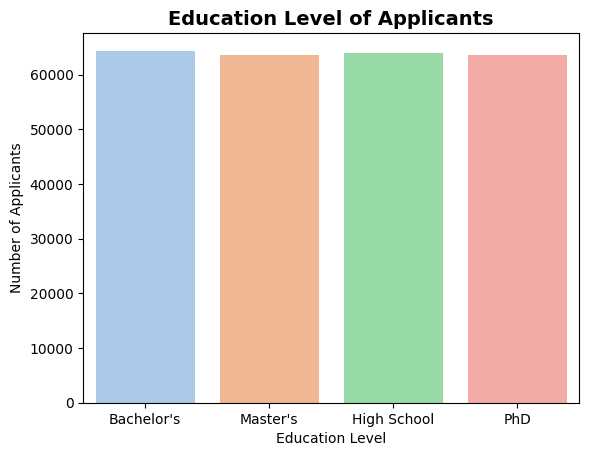

In [20]:
sns.countplot(x='education', data=df, palette='pastel')
plt.title('Education Level of Applicants', fontsize=14, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.show()


The key takeaway here is that the categories are perfectly balanced. We have an almost identical number of applicants from each educational background. This is highly improbable in a real-world scenario, where you would typically expect a pyramid-like structure with more people having lower levels of education

#### Employment Type

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\2581684719.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='employmenttype', data=df, palette='viridis')


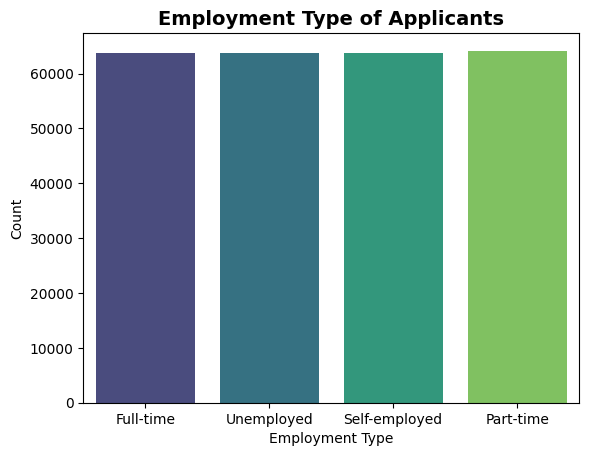

In [21]:
sns.countplot(x='employmenttype', data=df, palette='viridis')
plt.title('Employment Type of Applicants', fontsize=14, fontweight='bold')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.show()


In [22]:
print(df['employmenttype'].value_counts())


employmenttype
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64


Whether applicants are salaried, self-employed, or business owners — categories that can affect default risk.

#### Marital Status


C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\344655635.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='maritalstatus', data=df, palette='Set2')


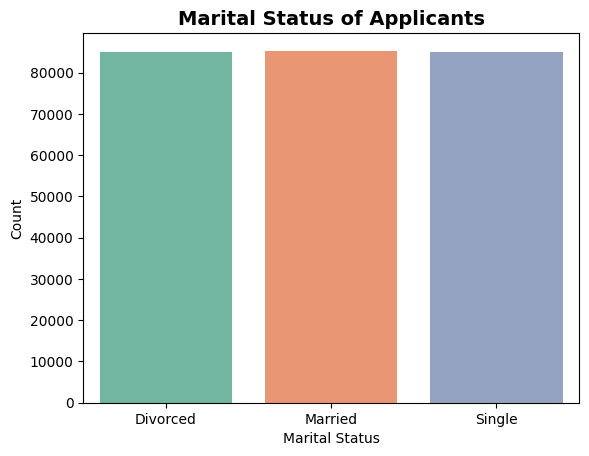

In [23]:
sns.countplot(x='maritalstatus', data=df, palette='Set2')
plt.title('Marital Status of Applicants', fontsize=14, fontweight='bold')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()


In [24]:
print(df['maritalstatus'].value_counts())

maritalstatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64


The proportion of married vs single applicants — helps check if family stability affects repayment likelihood.

#### Loan Purpose

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\3932879613.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loanpurpose', data=df, palette='coolwarm')


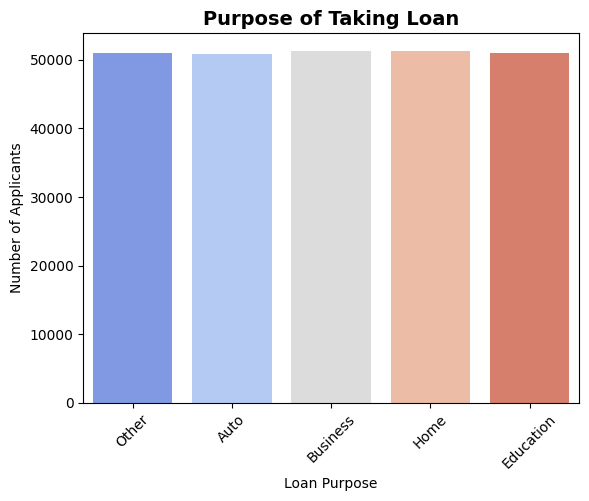

In [25]:
sns.countplot(x='loanpurpose', data=df, palette='coolwarm')
plt.title('Purpose of Taking Loan', fontsize=14, fontweight='bold')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=45)
plt.show()


In [26]:
print(df['loanpurpose'].value_counts())

loanpurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64


What loans are commonly taken for — e.g., home, education, personal, or car loans.

#### Loan Default Distribution (Target)

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\2872402915.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default', data=df, palette='Set1')


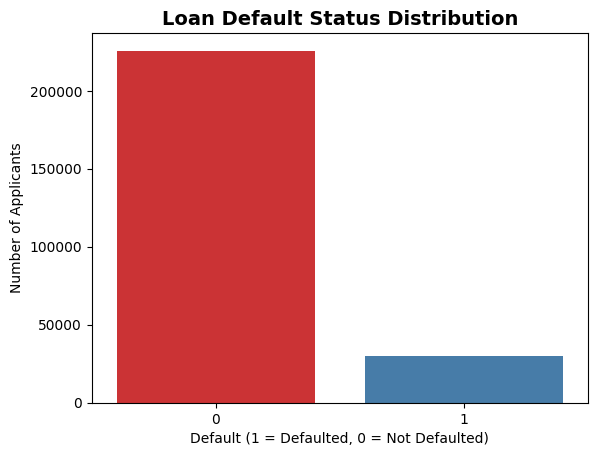

In [27]:
sns.countplot(x='default', data=df, palette='Set1')
plt.title('Loan Default Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Default (1 = Defaulted, 0 = Not Defaulted)')
plt.ylabel('Number of Applicants')
plt.show()


In [62]:
print(df['default'].value_counts())

default
0    225694
1     29653
Name: count, dtype: int64


How many customers defaulted vs repaid — important for identifying class imbalance before modeling.

## BIVARIATE ANALYSIS

#### Income vs Loan Defaul

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\2660219411.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='income', data=df, palette='Set3')


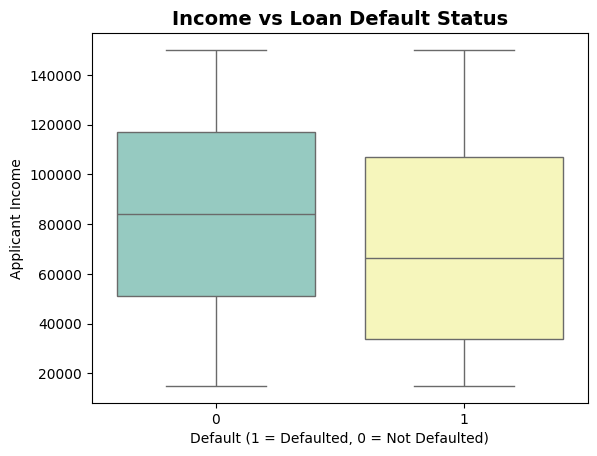

In [28]:
sns.boxplot(x='default', y='income', data=df, palette='Set3')
plt.title('Income vs Loan Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Default (1 = Defaulted, 0 = Not Defaulted)')
plt.ylabel('Applicant Income')
plt.show()


The key insight here is very clear: the median income for applicants who defaulted is significantly lower than the median income for those who repaid their loans. We can see the entire box for the 'Defaulted' group is shifted downwards

#### Credit Score vs Loan Default

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\122002481.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='creditscore', data=df, palette='cool')


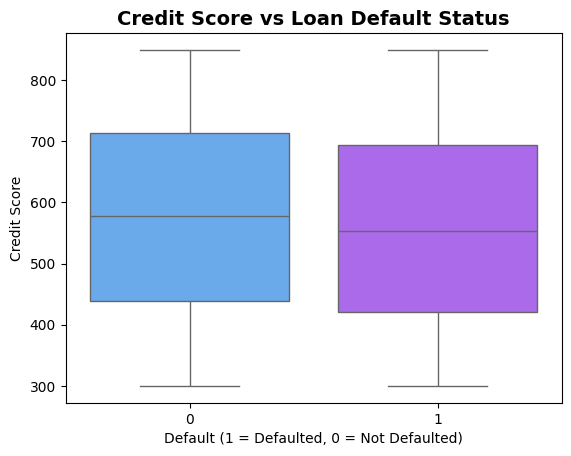

In [29]:
sns.boxplot(x='default', y='creditscore', data=df, palette='cool')
plt.title('Credit Score vs Loan Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Default (1 = Defaulted, 0 = Not Defaulted)')
plt.ylabel('Credit Score')
plt.show()


If defaulters generally have lower credit scores — a common financial risk indicator.

#### Debt-to-Income Ratio vs Loan Default

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\2584018040.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='dtiratio', data=df, palette='viridis')


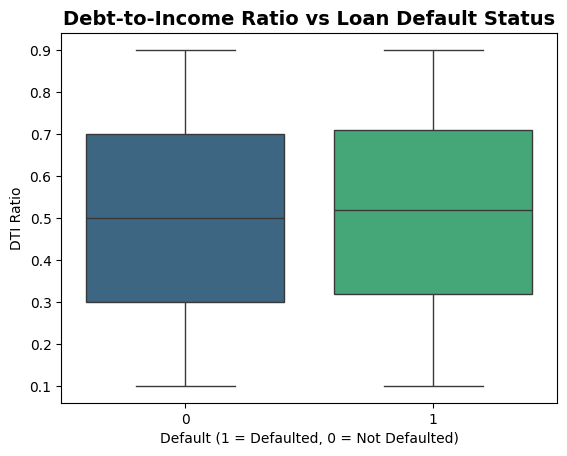

In [30]:
sns.boxplot(x='default', y='dtiratio', data=df, palette='viridis')
plt.title('Debt-to-Income Ratio vs Loan Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Default (1 = Defaulted, 0 = Not Defaulted)')
plt.ylabel('DTI Ratio')
plt.show()


If the median or upper quartile of DTI for defaulted loans is higher, it indicates that borrowers with higher debt relative to income are more likely to default.

#### Loan Amount vs Loan Default

C:\Users\shadi\AppData\Local\Temp\ipykernel_23340\3923762101.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default', y='loanamount', data=df, palette='mako')


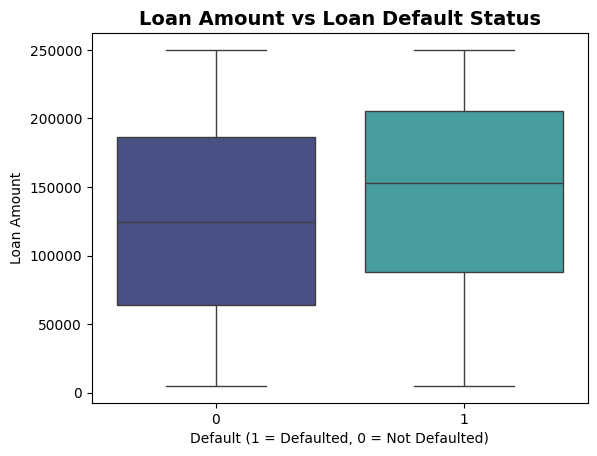

In [31]:
sns.boxplot(x='default', y='loanamount', data=df, palette='mako')
plt.title('Loan Amount vs Loan Default Status', fontsize=14, fontweight='bold')
plt.xlabel('Default (1 = Defaulted, 0 = Not Defaulted)')
plt.ylabel('Loan Amount')
plt.show()


If defaulters tend to have higher loan amounts, it indicates that bigger loans carry higher default probability

## Feature Engineering

#### Create New Features

We’ll create features that reflect financial strength, credit behavior, and loan structure.

In [32]:

# Fill numeric columns with median



df = df.fillna(df.median(numeric_only=True))

# Fill categorical columns with mode



for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])



# Loan-to-income ratio( already there but to ensure consistency)



df['loan_to_income'] = df['loanamount'] / df['income']

# Average credit per line



df['credit_per_line'] = df['creditscore'] / (df['numcreditlines'] + 1)



# Employment stability indicator



df['employment_stability'] = df['monthsemployed'] / (df['age'] * 12)

# Adjusted DTI ratio (debt-to-income ratio normalized)


df['adjusted_dti'] = df['dtiratio'] * df['loan_to_income']



# Interest burden: how costly loan is vs income


df['interest_burden'] = (df['interestrate'] / 100) * df['loanamount'] / df['income']


#### Transform Skewed Features

In [33]:
for col in ['loanamount', 'income', 'creditscore']:
    df[f'{col}_log'] = np.log1p(df[col])


Log transformation reduces skewness → helps models understand patterns better

#### Encode Categorical Variables

In [34]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding for binary or ordinal categories

label_encoder = LabelEncoder()
for col in ['education', 'employmenttype', 'maritalstatus', 
            'loanpurpose', 'hasmortgage', 'hasdependents', 'hascosigner']:
    df[col] = label_encoder.fit_transform(df[col])


Turns text categories (like “Married”, “Single”) into numerical codes without losing info.

#### Interaction Features

In [63]:
# Combine income and credit score effects


df['income_creditscore_interaction'] = df['income'] * df['creditscore']

# Combine DTI and loan term to show debt stress duration

df['dti_term_interaction'] = df['dtiratio'] * df['loanterm']

# Combine interest rate and credit score

df['interest_creditscore_interaction'] = df['interestrate'] * df['creditscore']

This combines income and credit score — because someone with high income and high credit score is much less likely to default than someone with only one of these high

This shows debt stress duration — if someone has a high debt-to-income ratio and also a long loan term, the repayment pressure is higher

This captures how interest rate and credit score interact — borrowers with low credit scores usually face higher interest rates, which can increase default risk

#### Scaling and Normalization

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


# Identify numeric columns to scale


num_cols = [
    'age', 'income', 'loanamount', 'creditscore', 'monthsemployed', 
    'numcreditlines', 'interestrate', 'loanterm', 'dtiratio',
    'loan_to_income', 'credit_per_line', 'employment_stability',
    'adjusted_dti', 'interest_burden'
]

df[num_cols] = scaler.fit_transform(df[num_cols])


Scaling is important because in a dataset, different numerical columns have different ranges — for example, income might be in lakhs, while interest rate might be in single digits.

Machine learning algorithms like Logistic Regression or SVM are sensitive to feature scales — features with large values can dominate smaller ones, which affects model performance.

So, I used the StandardScaler(), which standardizes the data by removing the mean and scaling it to unit variance.

#### Drop Unnecessary Columns

In [37]:
df = df.drop(['loanid'], axis=1)


loanid is just an identifier — it has no predictive meaning

#### final check

In [44]:
print(df.shape)
df.head()


(255347, 28)


,age,income,loanamount,creditscore,monthsemployed,numcreditlines,interestrate,loanterm,dtiratio,education,...,credit_per_line,employment_stability,adjusted_dti,interest_burden,loanamount_log,income_log,creditscore_log,income_creditscore_interaction,dti_term_interaction,interest_creditscore_interaction
0,0.833990,0.089693,-1.086833,-0.341492,0.590533,1.341937,0.261771,-0.001526,-0.260753,0,...,-0.945197,-0.126677,-0.638633,-0.571011,10.831470,11.362044,6.255750,44716880,15.84,7919.60
1,1.701221,-0.823021,-0.044309,-0.731666,-1.285731,-1.343791,-1.308350,1.412793,0.778585,2,...,0.529024,-1.147629,0.452348,-0.489624,11.731587,10.828401,6.129050,23097856,40.80,2202.98
2,0.166888,0.043854,0.022715,-0.775718,-0.968209,0.446694,1.156831,-0.708685,-0.823728,2,...,-0.842001,-0.854432,-0.471992,0.086915,11.769032,11.341057,6.113682,37977808,7.44,9547.67
3,-0.767053,-1.303452,-1.168538,1.061875,-1.718715,0.446694,-0.967805,-0.708685,-1.170174,1,...,0.018944,-1.330876,-0.587837,-0.542250,10.709963,10.364514,6.612041,23562759,5.52,5253.01
4,1.100830,-1.592855,-1.671921,0.369631,-1.487790,1.341937,-1.052188,0.705634,0.995114,0,...,-0.678658,-1.218484,-0.586658,-0.740204,9.120416,9.925151,6.452049,12936621,35.04,4120.83


#### Baseline Model - Dummy Classifier

Always predicting the most frequent class

In [46]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#### Initialize the Dummy Classifier

In [47]:
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)

#### Train the Dummy Classifier on the training data

In [48]:
dummy_model.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,42
,constant,None


#### Make predictions on the test set

In [49]:
y_dummy_pred = dummy_model.predict(X_test)

#### Evaluate the Dummy model

In [52]:
dummy_accuracy = accuracy_score(y_test, y_dummy_pred)
print(" Dummy Classifier Accuracy:", round(dummy_accuracy, 3))

 Dummy Classifier Accuracy: 0.884


In [53]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_dummy_pred))
print("\nClassification Report:\n", classification_report(y_test, y_dummy_pred))


Confusion Matrix:
 [[45139     0]
 [ 5931     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94     45139
           1       0.00      0.00      0.00      5931

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070



C:\Users\shadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\shadi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

The Dummy Classifier achieves 88% accuracy by always predicting the majority class (non-default).
However, it has zero recall and precision for the default class, meaning it cannot detect risky borrowers.
This baseline will be used to evaluate improvement when building real models like Logistic Regression next.


Top-left (45139) True Negatives — correctly predicted fully paid loans.

Top-right (0) False Positives — loans predicted as default but actually paid (none here).

Bottom-left (5931)  False Negatives — loans that actually defaulted but the model predicted as fully paid.

Bottom-right (0) True Positives — correctly predicted defaulted loans (none here)




Precision = Out of all the loans the model predicted as default, how many were actually default.
In simple terms, it measures how accurate the positive predictions are.

Recall =Out of all actual defaults, how many did the model correctly identify.
It measures how well the model captures actual positives.

F1-Score = The balance between precision and recall.

Support → The number of actual records for that class

#### Logistic Regression

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8866261993342471
ROC AUC: 0.758317436745873

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.99      0.94     45139
           1       0.61      0.07      0.12      5931

    accuracy                           0.89     51070
   macro avg       0.75      0.53      0.53     51070
weighted avg       0.86      0.89      0.84     51070



Accuracy: 0.8866 (≈ 88.6%)

The model correctly predicts about 88.6% of all cases.

This is almost the same accuracy as the dummy model (which was 88%),
but the difference is that this model actually learns from data and can now identify some of the people who default.

ROC AUC: 0.7583

This measures how well the model can separate defaulters (1) from non-defaulters (0).

The value ranges from 0.5 (bad) to 1.0 (perfect).

A score of 0.75 means the model does a good job at distinguishing between risky and safe borrowers


The Logistic Regression model achieved 88.6% accuracy and an AUC score of 0.75, showing that it can somewhat separate risky borrowers from safe ones.
However, the model is still biased toward non-defaulters, correctly predicting almost all people who repay their loans but identifying only a small portion (7%) of actual defaulters.
This indicates that while the model performs better than the dummy classifier, it still needs improvement to catch more default cases.

In [ ]:
1